<a href="https://colab.research.google.com/github/paramveer00758/summer-training/blob/main/Week2project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

california = fetch_california_housing(as_frame=True)

# Combine features and target into a single pandas DataFrame for exploration
df = california.frame

print("Dataset successfully loaded!")
print(f"Data dimensions: {df.shape[0]} rows and {df.shape[1]} columns.\n")
df.head()

Dataset successfully loaded!
Data dimensions: 20640 rows and 9 columns.



,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


--- Basic Statistical Summary ---
               count         mean          std         min         25%  \
MedInc       20640.0     3.870671     1.899822    0.499900    2.563400   
HouseAge     20640.0    28.639486    12.585558    1.000000   18.000000   
AveRooms     20640.0     5.429000     2.474173    0.846154    4.440716   
AveBedrms    20640.0     1.096675     0.473911    0.333333    1.006079   
Population   20640.0  1425.476744  1132.462122    3.000000  787.000000   
AveOccup     20640.0     3.070655    10.386050    0.692308    2.429741   
Latitude     20640.0    35.631861     2.135952   32.540000   33.930000   
Longitude    20640.0  -119.569704     2.003532 -124.350000 -121.800000   
MedHouseVal  20640.0     2.068558     1.153956    0.149990    1.196000   

                     50%          75%           max  
MedInc          3.534800     4.743250     15.000100  
HouseAge       29.000000    37.000000     52.000000  
AveRooms        5.229129     6.052381    141.909091  
AveBedrms

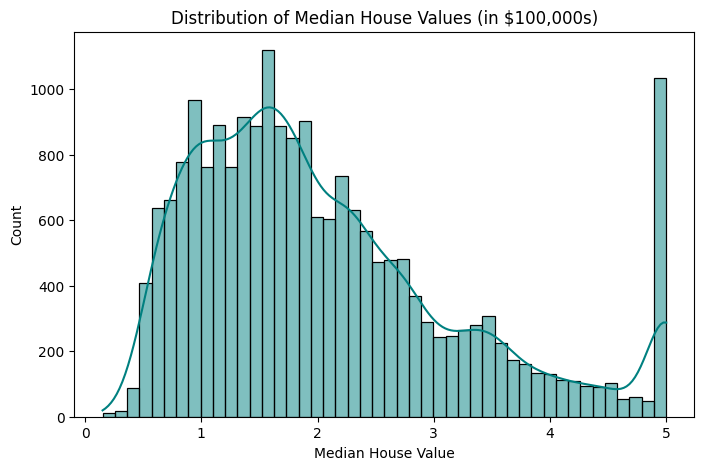

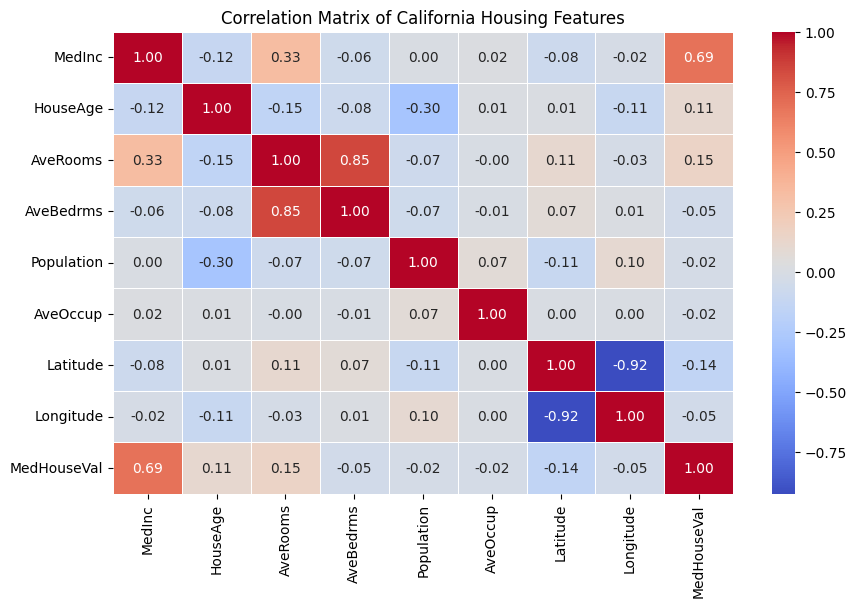

In [2]:
# Step 2: Basic Exploration and Visualization
print("--- Basic Statistical Summary ---")
print(df.describe().T)

# Visualizing the distribution of the target variable: MedHouseVal
plt.figure(figsize=(8, 5))
sns.histplot(df['MedHouseVal'], kde=True, color='teal')
plt.title('Distribution of Median House Values (in $100,000s)')
plt.xlabel('Median House Value')
plt.ylabel('Count')
plt.show()

# Quick correlation heatmap to see how features relate to the target
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of California Housing Features')
plt.show()

In [3]:
# Step 3: Train/Test Split & Feature Preprocessing

# Separate features (X) from the target price variable (y)
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

# Split dataset into 80% Training and 20% Testing sets
# random_state ensures the split is reproducible every time you run it
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples\n")

# Apply Feature Scaling using StandardScaler
# Scale data so all features have a mean of 0 and a standard deviation of 1.
# This prevents columns with large numbers from unfairly dominating the linear regression model.
scaler = StandardScaler()

# Fit the scaler on training data ONLY, then transform both train and test sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling successfully completed!")

Training set size: 16512 samples
Testing set size: 4128 samples

Feature scaling successfully completed!


In [4]:
# Step 4: Initialize and Train the Linear Regression Model
model = LinearRegression()

# Train the model on our scaled training features and target labels
model.fit(X_train_scaled, y_train)

print("Linear Regression model training is complete!")

Linear Regression model training is complete!


--- Model Evaluation Metrics ---
Mean Squared Error (MSE): 0.5559
R-squared Score (R2):      0.5758



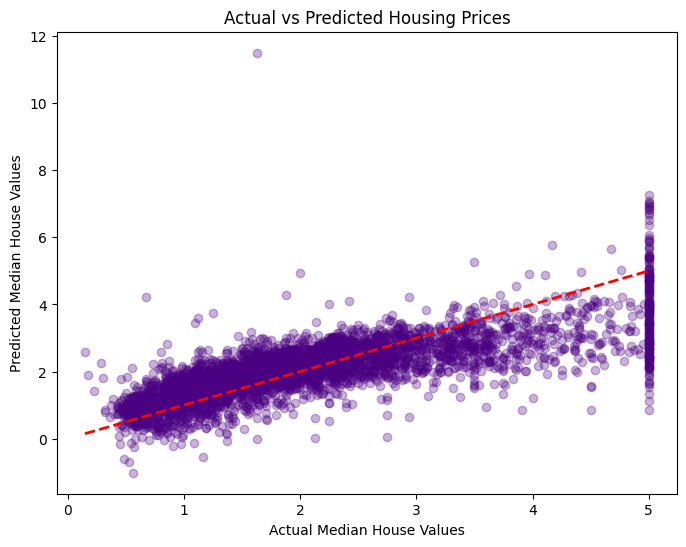

In [5]:
# Step 5: Evaluate the Model on Testing Data

# Make predictions using the unseen scaled test data
y_pred = model.predict(X_test_scaled)

# Calculate standard evaluation metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("--- Model Evaluation Metrics ---")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared Score (R2):      {r2:.4f}\n")

# Visual comparison: Actual vs Predicted Prices plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='indigo')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.xlabel('Actual Median House Values')
plt.ylabel('Predicted Median House Values')
plt.title('Actual vs Predicted Housing Prices')
plt.show()